In [90]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

import tensorflow as tf

from PIL import Image
import cv2

from sklearn import preprocessing
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

import xgboost
import warnings
warnings.filterwarnings("ignore")

In [91]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

base_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/"

train_pneumonia_dir = base_dir+'train/PNEUMONIA/'
train_normal_dir=base_dir+'train/NORMAL/'

test_pneumonia_dir = base_dir+'test/PNEUMONIA/'
test_normal_dir = base_dir+'test/NORMAL/'

val_normal_dir= base_dir+'val/NORMAL/'
val_pnrumonia_dir= base_dir+'val/PNEUMONIA/'

train_pn = [train_pneumonia_dir+"{}".format(i) for i in os.listdir(train_pneumonia_dir) ]
train_normal = [train_normal_dir+"{}".format(i) for i in os.listdir(train_normal_dir) ]

test_normal = [test_normal_dir+"{}".format(i) for i in os.listdir(test_normal_dir)]
test_pn = [test_pneumonia_dir+"{}".format(i) for i in os.listdir(test_pneumonia_dir)]

val_pn= [val_pnrumonia_dir+"{}".format(i) for i in os.listdir(val_pnrumonia_dir) ]
val_normal= [val_normal_dir+"{}".format(i) for i in os.listdir(val_normal_dir) ]

print ("Total images:",len(train_pn+train_normal+test_normal+test_pn+val_pn+val_normal))
print ("Total pneumonia images:",len(train_pn+test_pn+val_pn))
print ("Total Nomral images:",len(train_normal+test_normal+val_normal))

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/paultimothymooney
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val/NORMAL
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/PNEUMONIA
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test/NORMAL
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/datasets/paultimothymooney/chest-x

In [92]:
# Dataset Splitting (train 80% , test 15% and validation 5% )
import random
# Gathering all pneumina and normal chest X-ray in two python list
pn = train_pn + test_pn + val_pn #4273
normal = train_normal + test_normal + val_normal #1583

random.seed(10)
random.shuffle(pn)
random.shuffle(normal)

# Spliting dataset in train set,test set and validation set.

train_imgs = pn[855:]+ normal[316:]  # 80% of 4273 Pneumonia and 1583 normal chest X-ray .
test_imgs = pn[:641]+ normal[:237]
val_imgs = pn[641:855] + normal[237:316]

random.seed(10)
random.shuffle(train_imgs)
random.shuffle(test_imgs)
random.shuffle(val_imgs)

print("Total Train Images %s containing %s pneumonia and %s normal images" 
      % (len(train_imgs),3418,1266))
print("Total Test Images %s containing %s pneumonia and %s normal images"
      % (len(test_imgs),641,237))
print("Total validation Images %s containing %s pneumonia and %s normal images" 
      % (len(val_imgs),214,79))

Total Train Images 4685 containing 3418 pneumonia and 1266 normal images
Total Test Images 878 containing 641 pneumonia and 237 normal images
Total validation Images 293 containing 214 pneumonia and 79 normal images


In [93]:
def preprocess_image(image_list):

    X = []
    y = []

    for image in image_list:

        try:
            img = cv2.imread(image)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224,224))
            X.append(img)

        except:
            continue

        if 'NORMAL' in image:
            y.append(0)
        else:
            y.append(1)

    return np.array(X), np.array(y)

In [94]:
X_train, y_train = preprocess_image(train_imgs)
X_test, y_test = preprocess_image(test_imgs)
X_val, y_val = preprocess_image(val_imgs)

print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(4685, 224, 224, 3)
(878, 224, 224, 3)
(293, 224, 224, 3)


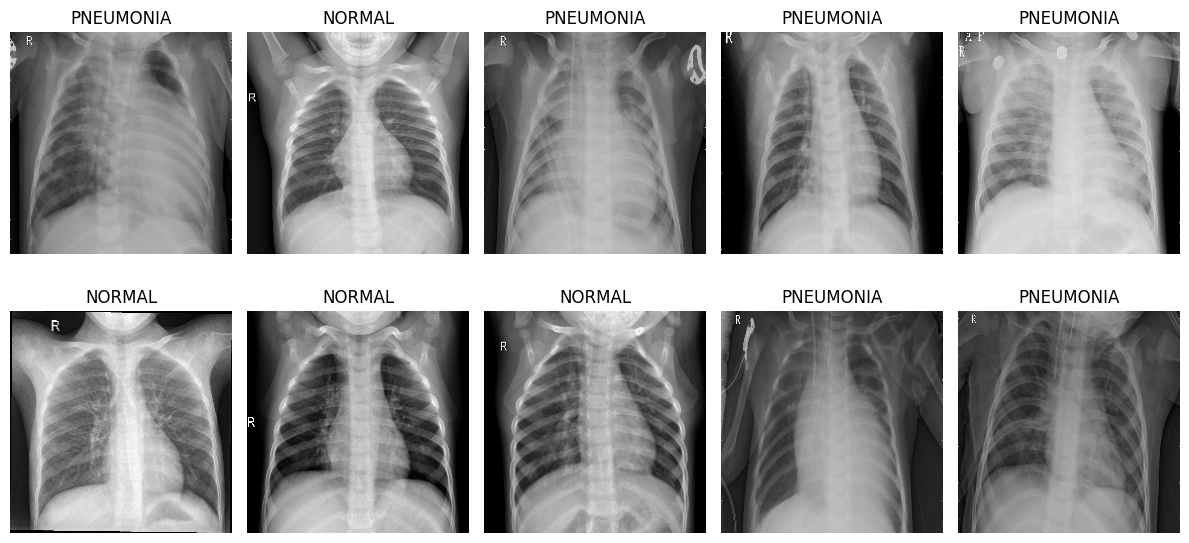

In [95]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i])

    plt.title("NORMAL" if y_train[i] == 0 else "PNEUMONIA")

    plt.axis("off")

plt.tight_layout()
plt.show()

In [96]:
from tensorflow.keras.applications import VGG16

IMG_SIZE = (224, 224)

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [97]:
base_model.trainable = False
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [98]:
print("Extracting training features...")
X_train_features = base_model.predict(X_train, verbose=1)

X_train_features = X_train_features.reshape(
    X_train_features.shape[0], -1
)

del X_train

print("Extracting validation features...")
X_val_features = base_model.predict(X_val, verbose=1)

X_val_features = X_val_features.reshape(
    X_val_features.shape[0], -1
)

del X_val

print("Extracting test features...")
X_test_features = base_model.predict(X_test, verbose=1)

X_test_features = X_test_features.reshape(
    X_test_features.shape[0], -1
)

del X_test

Extracting training features...
147/147 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step
Extracting validation features...
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
Extracting test features...
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step


In [99]:
print(X_train_features.shape)
print(X_val_features.shape)
print(X_test_features.shape)

(4685, 25088)
(293, 25088)
(878, 25088)


In [100]:
from xgboost import XGBClassifier

xgb_params = {
    'objective': 'binary:logistic',
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': ['error', 'logloss'],
    'verbosity': 1
}

xgb_model = XGBClassifier(**xgb_params)

In [101]:
xgb_model.fit(
    X_train_features,
    y_train,
    eval_set=[
        (X_train_features, y_train),
        (X_val_features, y_val)
    ],
    verbose=True
)

[0]	validation_0-error:0.27044	validation_0-logloss:0.50990	validation_1-error:0.26962	validation_1-logloss:0.51758
[1]	validation_0-error:0.27044	validation_0-logloss:0.45278	validation_1-error:0.26962	validation_1-logloss:0.46471
[2]	validation_0-error:0.27044	validation_0-logloss:0.40583	validation_1-error:0.26962	validation_1-logloss:0.42811
[3]	validation_0-error:0.11740	validation_0-logloss:0.36598	validation_1-error:0.13993	validation_1-logloss:0.39484
[4]	validation_0-error:0.08004	validation_0-logloss:0.33315	validation_1-error:0.12287	validation_1-logloss:0.36677
[5]	validation_0-error:0.05486	validation_0-logloss:0.30265	validation_1-error:0.09556	validation_1-logloss:0.34149
[6]	validation_0-error:0.04013	validation_0-logloss:0.27626	validation_1-error:0.08191	validation_1-logloss:0.32068
[7]	validation_0-error:0.03074	validation_0-logloss:0.25398	validation_1-error:0.08874	validation_1-logloss:0.30383
[8]	validation_0-error:0.02668	validation_0-logloss:0.23353	validation_1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=['error', 'logloss'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [102]:
print(X_train_features.shape)
print(X_val_features.shape)
print(X_test_features.shape)

(4685, 25088)
(293, 25088)
(878, 25088)


In [103]:
results = xgb_model.evals_result()

train_error = results['validation_0']['error']
train_acc = [1.0 - i for i in train_error]

val_error = results['validation_1']['error']
val_acc = [1.0 - i for i in val_error]

train_logloss = results['validation_0']['logloss']
val_logloss = results['validation_1']['logloss']

import numpy as np

best_round = np.argmin(val_logloss)

print("Best Boosting Round :", best_round + 1)
print("Lowest Validation Log Loss :", min(val_logloss))

Best Boosting Round : 129
Lowest Validation Log Loss : 0.0926178885193364


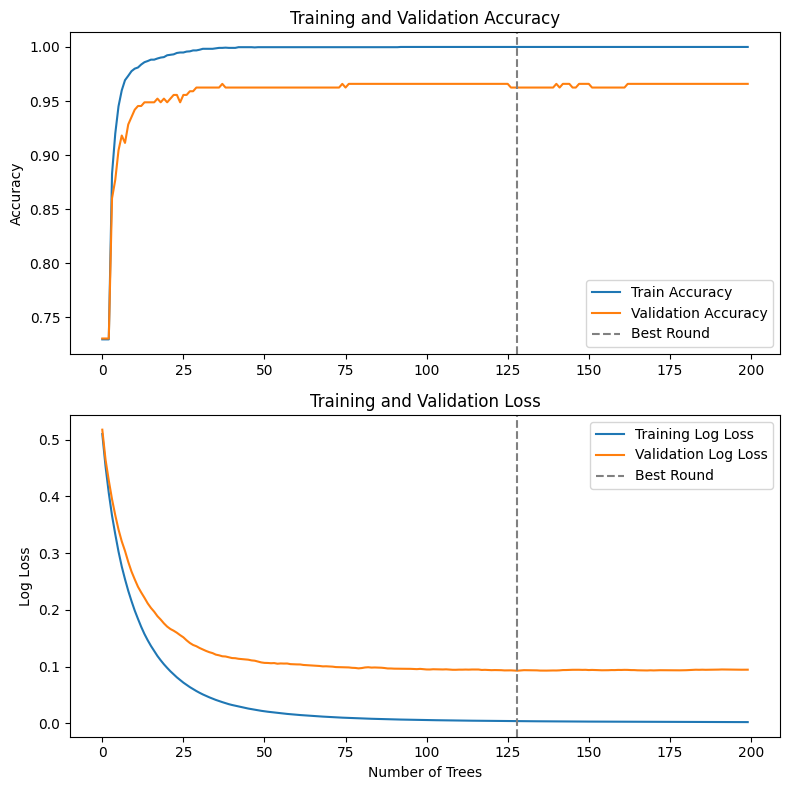

In [104]:
plt.figure(figsize=(8,8))

plt.subplot(2,1,1)
plt.plot(train_acc, label='Train Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.axvline(best_round, color='gray', linestyle='--',
            label='Best Round')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2,1,2)
plt.plot(train_logloss, label='Training Log Loss')
plt.plot(val_logloss, label='Validation Log Loss')
plt.axvline(best_round, color='gray', linestyle='--',
            label='Best Round')
plt.ylabel('Log Loss')
plt.xlabel('Number of Trees')
plt.legend()
plt.title('Training and Validation Loss')

plt.tight_layout()
plt.show()

In [105]:
train_predictions = xgb_model.predict(X_train_features)
val_predictions = xgb_model.predict(X_val_features)
test_predictions = xgb_model.predict(X_test_features)

print("Training Accuracy = ",accuracy_score(y_train, train_predictions))
print("Test Accuracy = ",accuracy_score(y_test, test_predictions))
print("Validation Accuracy = ",accuracy_score(y_val, val_predictions))

Training Accuracy =  1.0
Test Accuracy =  0.9669703872437357
Validation Accuracy =  0.9658703071672355


In [106]:
predictions = xgb_model.predict(X_test_features)

print("Evaluating the Algorithm\n")

print("Accuracy :", accuracy_score(y_test, predictions))
print("Precision:", precision_score(y_test, predictions, average='weighted'))
print("Recall   :", recall_score(y_test, predictions, average='weighted'))
print("F1 Score :", f1_score(y_test, predictions, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Evaluating the Algorithm

Accuracy : 0.9669703872437357
Precision: 0.9668654527275898
Recall   : 0.9669703872437357
F1 Score : 0.9669037533623914

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.93      0.94       237
           1       0.98      0.98      0.98       641

    accuracy                           0.97       878
   macro avg       0.96      0.96      0.96       878
weighted avg       0.97      0.97      0.97       878

